# Visualización multiple de imputaciones

Vamos a aprender como realizar este tipo de visualizaciones para 1, 2 o más variables. Hagamoslo!

## Preparación de datos

#### Importando librerías

In [1]:
### Importando librerías
import janitor      #Crear pipelines de limpieza de datos
import matplotlib.pyplot as plt
import missingno    #Visualizar valores faltantes 
import numpy as np
import pandas as pd
import pyreadr      #Leer archivos adr para este curso
import seaborn as sns
import session_info
import upsetplot    #Para gráfica de relaciones 
                    #de nuestros valores faltantes

#### Configurar el aspecto general de las gráficas del proyecto

In [2]:
%matplotlib inline

sns.set(
    rc={
        "figure.figsize": (10, 10)
    }
)

sns.set_style("whitegrid")

#### Leer conjunto de datos

In [3]:
#Cargar conjunto de datos
riskfactors = pyreadr.read_r('dataset/riskfactors.rda')

#Convertirlo a Data Frame
riskfactors_df = next(iter(riskfactors.values()))

#Borrar el diccionario
del riskfactors

#### Añadir extensión de Pandas

In [5]:
%run pandas-missing-extension-re2.py

In [7]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    
)

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/3988945165.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


,weight_lbs,height_inch,bmi,weight_lbs_NA,height_inch_NA,bmi_NA
0,190.0,64.0,32.68,False,False,False
1,170.0,68.0,25.90,False,False,False
2,163.0,64.0,28.04,False,False,False
3,230.0,74.0,29.59,False,False,False
4,135.0,62.0,24.74,False,False,False
...,...,...,...,...,...,...
240,144.0,63.0,25.56,False,False,False
241,170.0,74.0,21.87,False,False,False
242,175.0,71.0,24.46,False,False,False
243,138.0,64.0,23.74,False,False,False


Vamos a pivotar nuestra tabla

In [8]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
)

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/3252663045.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


,weight_lbs_NA,height_inch_NA,bmi_NA,variable,value
0,False,False,False,weight_lbs,190.00
1,False,False,False,weight_lbs,170.00
2,False,False,False,weight_lbs,163.00
3,False,False,False,weight_lbs,230.00
4,False,False,False,weight_lbs,135.00
...,...,...,...,...,...
730,False,False,False,bmi,25.56
731,False,False,False,bmi,21.87
732,False,False,False,bmi,24.46
733,False,False,False,bmi,23.74


Lo que vemos es que tenemos nuestras columnas con datos imputados y una reducción a 2 columnas:
1. Variable: Contiene el encabezado de la variable correspondiente.
2. Value: Contiene los valores de la variable correspondiente para la entrada correspondiente 

Ahora lo que necesitamos es que tenga un formato adecuado. Vamos a realizar otro pivote.

In [9]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
    .pivot_longer(
        index=['variable','value'],
        names_to='variable_NA',
        values_to='value_NA'
    )
)

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/2051958734.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


,variable,value,variable_NA,value_NA
0,weight_lbs,190.00,weight_lbs_NA,False
1,weight_lbs,170.00,weight_lbs_NA,False
2,weight_lbs,163.00,weight_lbs_NA,False
3,weight_lbs,230.00,weight_lbs_NA,False
4,weight_lbs,135.00,weight_lbs_NA,False
...,...,...,...,...
2200,bmi,25.56,bmi_NA,False
2201,bmi,21.87,bmi_NA,False
2202,bmi,24.46,bmi_NA,False
2203,bmi,23.74,bmi_NA,False


Como se puede observar tenemos aquí un mejor orden para ver si tenemos un valor faltante en nuestras columnas.

**A ESTE FORMATO DE DATOS SE LE CONOCE COMO UN**
### CONJUNTO TIDY

De tal manera que cada columna represente una información. Ahora vamos a obtener una nueva columna.

In [13]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
    .pivot_longer(
        index=['variable','value'],
        names_to='variable_NA',
        values_to='value_NA'
    )
    .assign(
        valid=lambda df:df.apply(axis='columns',func=lambda column:column.variable in column.variable_NA)
    )
    .query('valid')
)

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/3240961081.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


,variable,value,variable_NA,value_NA,valid
0,weight_lbs,190.00,weight_lbs_NA,False,True
1,weight_lbs,170.00,weight_lbs_NA,False,True
2,weight_lbs,163.00,weight_lbs_NA,False,True
3,weight_lbs,230.00,weight_lbs_NA,False,True
4,weight_lbs,135.00,weight_lbs_NA,False,True
...,...,...,...,...,...
2200,bmi,25.56,bmi_NA,False,True
2201,bmi,21.87,bmi_NA,False,True
2202,bmi,24.46,bmi_NA,False,True
2203,bmi,23.74,bmi_NA,False,True


Terminamos con un Data Frame más pequeño que podamos visualizar.

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/1567325295.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


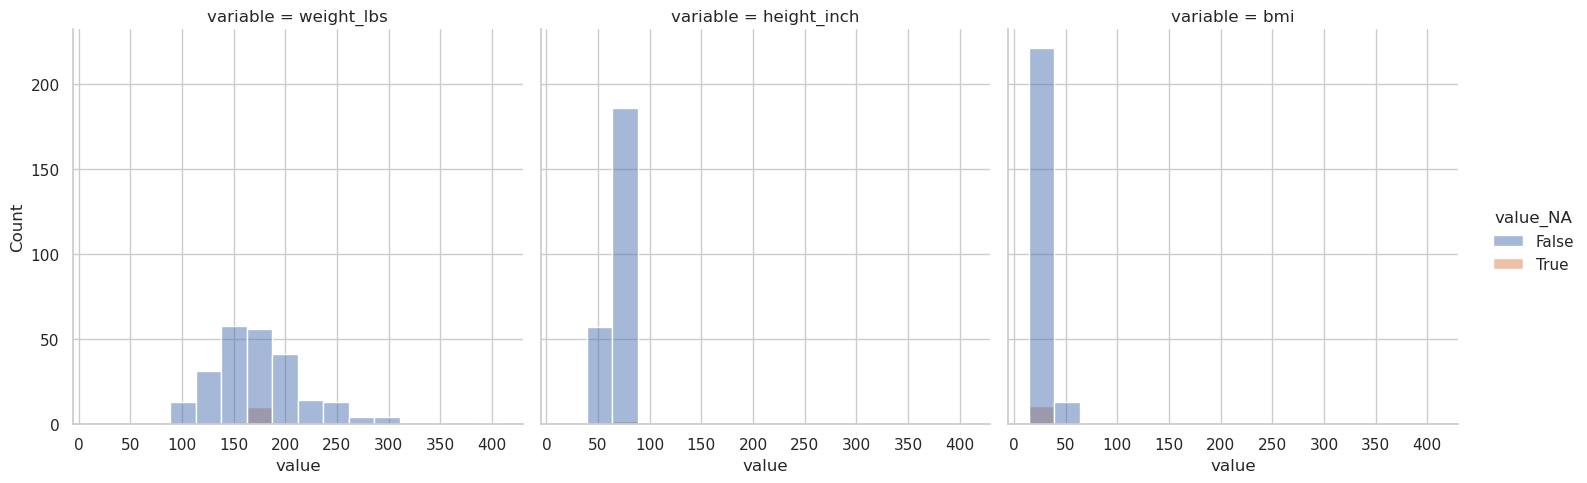

In [14]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
    .pivot_longer(
        index=['variable','value'],
        names_to='variable_NA',
        values_to='value_NA'
    )
    .assign(
        valid=lambda df:df.apply(axis='columns',func=lambda column:column.variable in column.variable_NA)
    )
    .query('valid')
    .pipe(
        lambda df:(
            sns.displot(
                data=df,
                x='value',
                hue='value_NA',
                col='variable',
            )
        )
    )
)

Con el parámetro `col` dibujamos un histograma para cada una de nuestras variables.

Cada gráfica nos muestra sus imputaciones, como se puede observar no tenemos una mejor percepción de los valores faltantes, porque todos se están agrupado de igual forma, este comportamiento no es tan apropiado.

Realizaremos lo siguiente:

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/3901499235.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


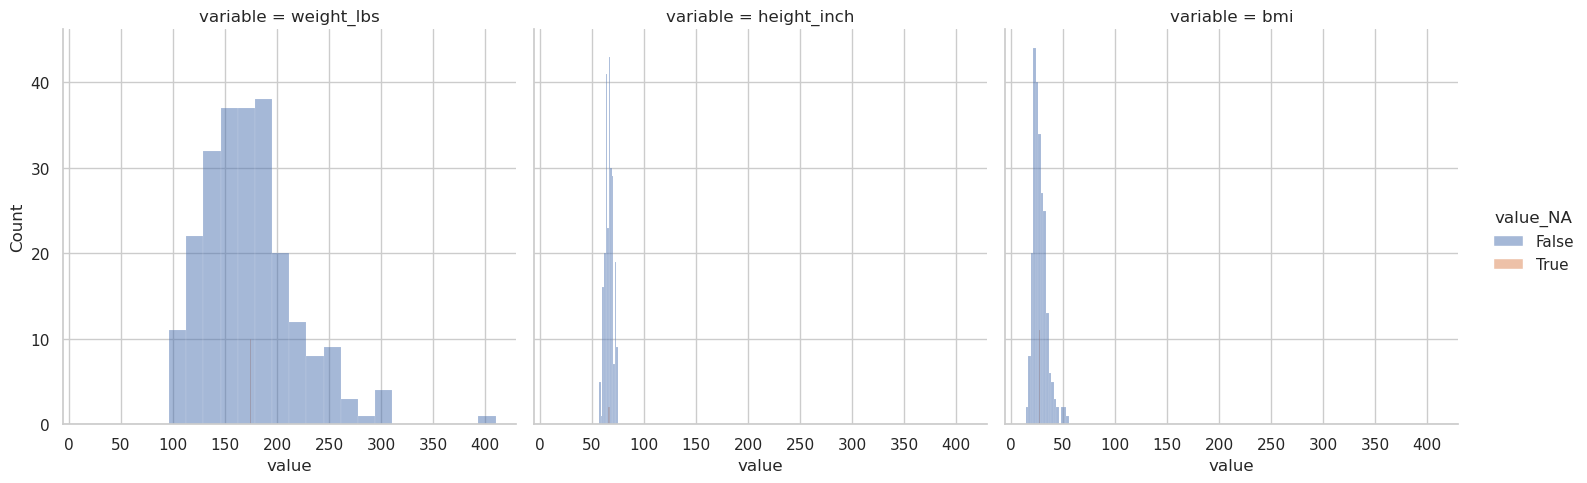

In [15]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
    .pivot_longer(
        index=['variable','value'],
        names_to='variable_NA',
        values_to='value_NA'
    )
    .assign(
        valid=lambda df:df.apply(axis='columns',func=lambda column:column.variable in column.variable_NA)
    )
    .query('valid')
    .pipe(
        lambda df:(
            sns.displot(
                data=df,
                x='value',
                hue='value_NA',
                col='variable',
                common_bins=False
            )
        )
    )
)

Aún así no nos deja ver adecuadamente, lo podemos solucionar con otro parámetro.

/home/dens/miniforge3/envs/deteccion/lib/python3.9/site-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `jn.select` instead.
  return method(self._obj, *args, **kwargs)
/tmp/ipykernel_5276/79994435.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)


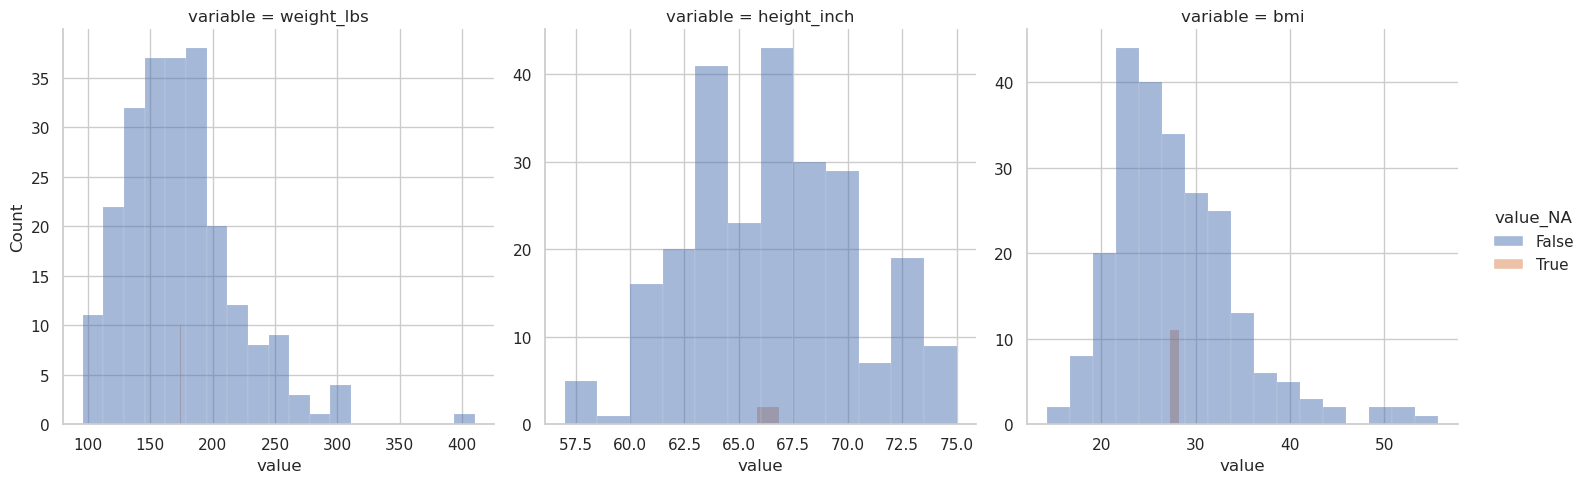

In [16]:
(
    riskfactors_df
    .select_columns('weight_lbs','height_inch','bmi')
    .missing.bind_shadow_matrix(true_string=True,false_string=False)
    .apply(
        axis='rows',
        func=lambda column: column.fillna(column.mean() if '_NA' not in column.name else column)
    )
    .pivot_longer(
        index='*_NA' #Usamos wildcard (todo lo que sea, seguido de _NA)
    )
    .pivot_longer(
        index=['variable','value'],
        names_to='variable_NA',
        values_to='value_NA'
    )
    .assign(
        valid=lambda df:df.apply(axis='columns',func=lambda column:column.variable in column.variable_NA)
    )
    .query('valid')
    .pipe(
        lambda df:(
            sns.displot(
                data=df,
                x='value',
                hue='value_NA',
                col='variable',
                common_bins=False,
                facet_kws={"sharex":False,
                           "sharey":False},
            )
        )
    )
)

Con los parámetros:

```py
facet_kws={"sharex":False,"sharey":False},
```     
Le estamos indicando que no debe compartir los ejes.

Así con esto podemos ver en donde se han imputado los valores faltantes, en este caso la media. Pero hay veces que se imputan valores con más ruido y cosas más complejas, así que esto nos servirá para saber que hacer y tener una referencia.